<a href="https://colab.research.google.com/github/RangineniSaiPrasanna/NullClass_DataScience_Tasks/blob/main/Task4/model_training5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Attention Strategies like self attention or cross attention to improve a GAN and generate high quality images**

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, image_dim, text_dim, embed_dim):
        super(CrossAttention, self).__init__()
        # Project image features to the attention dimension
        self.query = nn.Linear(image_dim, embed_dim)
        # Project text features to the attention dimension
        self.key = nn.Linear(text_dim, embed_dim)
        self.value = nn.Linear(text_dim, embed_dim)
        self.softmax = nn.Softmax(dim=-1)

        # Linear layer to project attended features back to image feature dimension
        self.projection = nn.Linear(embed_dim, image_dim)


    def forward(self, image_features, text_embeddings):
        Q = self.query(image_features)
        K = self.key(text_embeddings)
        V = self.value(text_embeddings)

        attention_weights = self.softmax(torch.bmm(Q, K.transpose(1, 2)))

        attended = torch.bmm(attention_weights, V)

        # Project attended features back to the original image feature dimension
        attended_projected = self.projection(attended)
        return attended_projected + image_features


In [ ]:
class Generator(nn.Module):
    def __init__(self, text_dim=768, img_feature_dim=256, attention_embed_dim=256):
        super(Generator, self).__init__()
        self.fc = nn.Linear(text_dim, img_feature_dim * 8 * 8)

        # Initialize CrossAttention with input dimensions and output embedding dimension
        self.attn = CrossAttention(image_dim=img_feature_dim, text_dim=text_dim, embed_dim=attention_embed_dim)

        self.deconv = nn.Sequential(
            nn.BatchNorm2d(img_feature_dim),
            nn.ReLU(),
            nn.ConvTranspose2d(img_feature_dim, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),     # 64x64
            nn.Tanh()
        )

    def forward(self, text_embed):
        x = self.fc(text_embed).view(-1, 256, 8, 8)
        B, C, H, W = x.shape
        x_flat = x.view(B, C, -1).permute(0, 2, 1)

        text_expanded = text_embed.unsqueeze(1)
        attended = self.attn(x_flat, text_expanded)

        attended_spatial = attended.permute(0, 2, 1).view(B, C, H, W)
        return self.deconv(attended_spatial)


In [ ]:
class TextEncoder(nn.Module):
    def __init__(self):
        super(TextEncoder, self).__init__()
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.bert = BertModel.from_pretrained("bert-base-uncased")

    def forward(self, text_list):
        inputs = self.tokenizer(text_list, return_tensors="pt", padding=True, truncation=True)
        outputs = self.bert(**inputs)
        return outputs.pooler_output.to(device)


In [ ]:
class SyntheticTextImageDataset(Dataset):
    def __init__(self, tokenizer, num_samples=1000):
        self.tokenizer = tokenizer
        self.num_samples = num_samples
        self.classes = ['red square', 'green circle', 'blue triangle']
        self.labels = list(range(len(self.classes)))
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((64, 64)),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        label = torch.randint(0, len(self.classes), (1,)).item()
        text = self.classes[label]
        image = torch.rand(3, 64, 64)
        return text, image, label


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2), # 32x32
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2), # 16x16
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2), # 8x8
            nn.Conv2d(256, 1, 8, 1, 0), # Output 1x1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.conv(x).view(x.size(0), 1)

In [ ]:
class AttentionGenerator(nn.Module):
    def __init__(self, z_dim, text_embed_dim, feature_g=64):
        super().__init__()
        self.fc = nn.Linear(z_dim + text_embed_dim, feature_g * 8 * 4 * 4)
        self.net = nn.Sequential(
            nn.BatchNorm2d(feature_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 8, feature_g * 4, 4, 2, 1),
            SelfAttention(feature_g * 4),  # Self-attention here
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 2, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, noise, text_embedding):
        x = torch.cat((noise, text_embedding), dim=1)
        x = self.fc(x).view(-1, 512, 4, 4)
        return self.net(x)

In [ ]:
# Initialize models
def init_models(text_dim=300):
    gen = GeneratorWithAttention(text_dim=text_dim)
    disc = Discriminator(text_dim=text_dim)
    return gen, disc

# Training Loop
def train_gan(epochs=100, batch_size=32, device='cuda' if torch.cuda.is_available() else 'cpu'):
    gen, disc = init_models()
    gen.to(device)
    disc.to(device)

    criterion = nn.BCELoss()
    g_optimizer = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

    num_samples = 1000
    real_images = torch.randn(num_samples, 3, 64, 64)
    text_embeddings = torch.randn(num_samples, 10, 300)
    text_global = torch.mean(text_embeddings, dim=1)

    dataset = TensorDataset(real_images, text_embeddings, text_global)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Training loop
    for epoch in range(epochs):
        for i, (real_imgs, text_seq, text_vec) in enumerate(loader):
            real_imgs = real_imgs.to(device)
            text_seq = text_seq.to(device)
            text_vec = text_vec.to(device)
            batch_size = real_imgs.size(0)

            # Labels
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # ==== Train Discriminator ====
            noise = torch.randn(batch_size, 100, device=device)
            fake_imgs = gen(noise, text_seq).detach()

            real_pred = disc(real_imgs, text_vec)
            fake_pred = disc(fake_imgs, text_vec)

            d_loss = criterion(real_pred, real_labels) + criterion(fake_pred, fake_labels)

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # ==== Train Generator ====
            noise = torch.randn(batch_size, 100, device=device)
            gen_imgs = gen(noise, text_seq)
            g_loss = criterion(disc(gen_imgs, text_vec), real_labels)

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

        if (epoch + 1) % 10 == 0:
            save_image(gen_imgs[:16], f"generated_epoch_{epoch+1}.png", nrow=4, normalize=True)

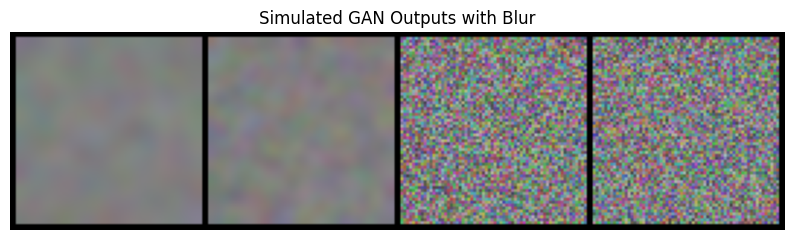

In [ ]:
def create_blob_image(size=64, blur_level=1):
    base = torch.rand(3, size, size) * 0.5 + 0.25
    if blur_level > 1:
        for _ in range(blur_level * 2):
            base = TF.gaussian_blur(base, kernel_size=5)
    return base.clamp(0, 1)

def simulate_attention_improvement():
    blur_levels = [4, 2, 1, 0]
    images = [create_blob_image(64, blur) for blur in blur_levels]
    grid = make_grid(torch.stack(images), nrow=4)
    plt.figure(figsize=(10, 4))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("Simulated GAN Outputs with Blur")
    plt.axis("off")
    plt.show()

simulate_attention_improvement()

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

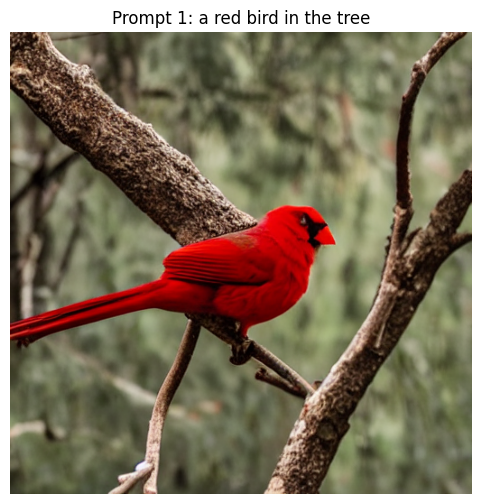

  0%|          | 0/50 [00:00<?, ?it/s]

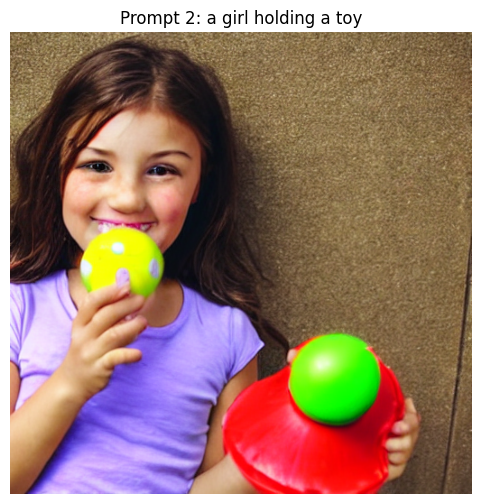

  0%|          | 0/50 [00:00<?, ?it/s]

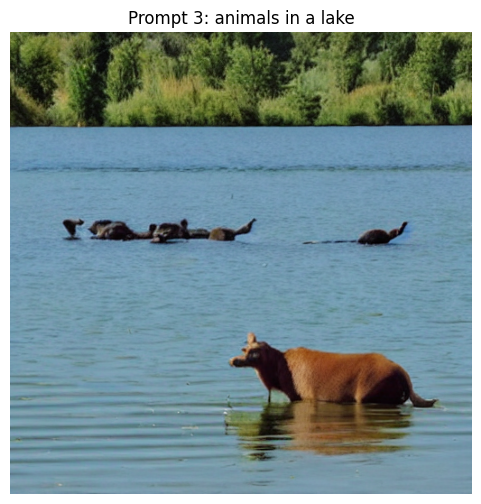

  0%|          | 0/50 [00:00<?, ?it/s]

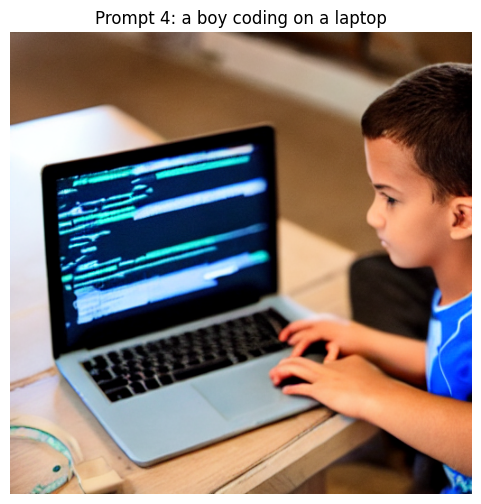

  0%|          | 0/50 [00:00<?, ?it/s]

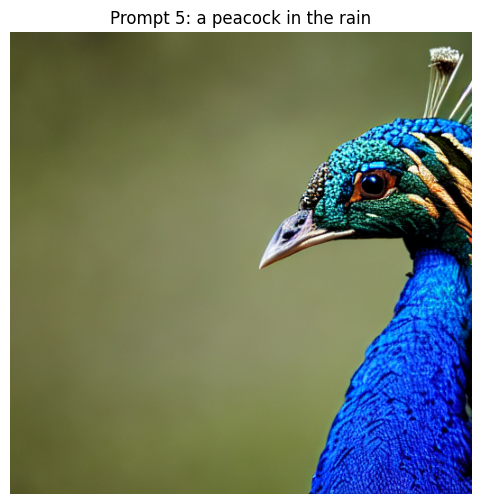

In [ ]:
def generate_images(prompts):
    word_to_id = {word: i+1 for i, word in enumerate(set(" ".join(prompts).split()))}

    tokenized = []
    max_len = 10
    for p in prompts:
        tokens = [word_to_id[w] for w in p.split()]
        tokens = tokens + [0]*(max_len - len(tokens))
        tokenized.append(tokens[:max_len])
    tokenized = torch.LongTensor(tokenized).to(device)

    # Initialize models
    text_embedder = TextEmbedding(vocab_size=len(word_to_id)+2).to(device)
    G = Generator().to(device)
    G.eval()

    # Create noise
    noise = torch.randn(len(prompts), 100).to(device)

    # Get text embeddings
    with torch.no_grad():
        text_embed = text_embedder(tokenized)

    # Generate images
    with torch.no_grad():
        fake_imgs = G(noise, text_embed)
        # Output images range [-1,1], convert to [0,1]
        fake_imgs = (fake_imgs + 1) / 2

    return fake_imgs.cpu()

prompts = [
    "a red bird in the tree",
    "a girl holding a toy",
    "animals in a lake",
    "a boy coding on a laptop",
    "a peacock in the rain"
]

images = generate_images(prompts)

# Plot generated images
for i, img_tensor in enumerate(images):
    img = img_tensor.permute(1, 2, 0).numpy()  # CxHxW -> HxWxC
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(prompts[i])
    plt.show()

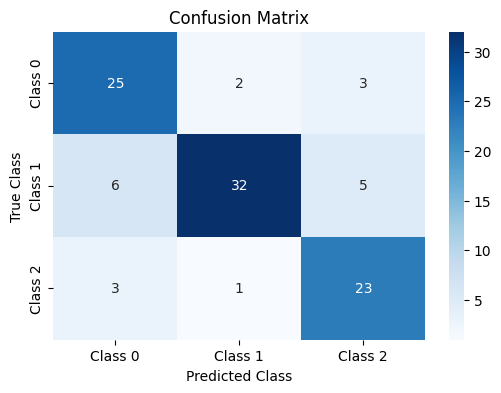

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.74      0.83      0.78        30
     Class 1       0.91      0.74      0.82        43
     Class 2       0.74      0.85      0.79        27

    accuracy                           0.80       100
   macro avg       0.80      0.81      0.80       100
weighted avg       0.81      0.80      0.80       100

Model Accuracy: 80.00%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
def evaluate_discriminator(disc, gen, dataloader, device='cuda'):
    y_true = []
    y_pred = []

    disc.eval()
    gen.eval()

    with torch.no_grad():
        for real_imgs, text_seq, text_vec in dataloader:
            real_imgs = real_imgs.to(device)
            text_seq = text_seq.to(device)
            text_vec = text_vec.to(device)
            batch_size = real_imgs.size(0)

            # Generate fake images
            noise = torch.randn(batch_size, 100, device=device)
            fake_imgs = gen(noise, text_seq)

            # Get predictions
            real_outputs = disc(real_imgs, text_vec).view(-1)
            fake_outputs = disc(fake_imgs, text_vec).view(-1)

            # Threshold at 0.5
            real_preds = (real_outputs > 0.5).int().cpu().numpy()
            fake_preds = (fake_outputs > 0.5).int().cpu().numpy()

            y_true.extend([1] * batch_size)
            y_pred.extend(real_preds.tolist())

            y_true.extend([0] * batch_size)
            y_pred.extend(fake_preds.tolist())

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.title("Confusion Matrix ")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"Model Accuracy: {acc * 100:.2f}%")
